In [1]:
%matplotlib inline

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm.notebook import tqdm

In [ ]:
# Define orbit parameters from the table
orbits = {
    'A': {'eccentricity': 0.1, 'semi_major_axis': 7000},  # km
    'B': {'eccentricity': 0.9, 'semi_major_axis': 70000}, # km  
    'C': {'eccentricity': 2.0, 'semi_major_axis': -7000},  # km (hyperbolic orbit)
    'D': {'eccentricity': 0.0, 'semi_major_axis': 7000} ,  # km (circular orbit)
    'E': {'eccentricity': 1.0, 'semi_major_axis': -7000}  # km (parabolic orbit)
}

mu = 3.986e5 # km^3/s^2

In [4]:
def two_body_ode(t, state):
    """Two-body orbital dynamics ODE"""
    r_vec, v_vec = state[:2], state[2:]
    r_vec_norm = np.sqrt(r_vec.T @ r_vec)
    a_vec = -mu * r_vec / r_vec_norm**3
    return np.concatenate([v_vec, a_vec])

# Algorithm KepEqtnE in [1, pp. 232]
# [1] Vallado, D.A., 1997. Fundamentals of astrodynamics and applications.
# https://github.com/decenter2021/osculating2mean/blob/af1966d912374a24204a166ede0354d76e74c686/OEOsc2rv.m#L62
def kepler_equation_solution(M, e, max_iter=10, epsilon=1e-8):
    if e < 1.0:
        # Elliptic case: solve for E
        M = np.mod(M, 2*np.pi)  # optional, wrap M
        if (-np.pi < M < 0) or (M > np.pi):
            E = M - e
        else:
            E = M + e

        for _ in range(max_iter):
            f  = E - e*np.sin(E) - M
            fp = 1 - e*np.cos(E)
            dE = -f / fp
            E += dE
            if abs(dE) < epsilon:
                return E

        print("Max iters reached (elliptic).")
    return E

def analytical_solution(t, a, e):
    """Analytical solution using Kepler's equation for both elliptical and hyperbolic orbits"""
    n = np.sqrt(mu / np.abs(a)**3)  # mean motion (use abs(a) for hyperbolic orbits)
    M = n * t  # mean anomaly
    
    E = kepler_equation_solution(M, e)
    r_vec_norm = a * (1 - e * np.cos(E))
    theta = 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E / 2))

    x = r_vec_norm * np.cos(theta)
    y = r_vec_norm * np.sin(theta)
    
    r_vec = np.array([x, y])
    
    return x, y, theta, r_vec, r_vec_norm

In [5]:
# Define multiple time steps to study
dt_values = [100, 50, 20, 10, 5, 2]  # time steps [s] to test
orbit_to_use = 'B'

a = orbits[orbit_to_use]['semi_major_axis']  # km
e = orbits[orbit_to_use]['eccentricity']

# Initial conditions at perigee (OTHERWISE THE ANALYTICAL SOLUTION IS NOT ALIGNED)
theta0 = 0
p = a * (1 - e**2)  # km
r0 = p / (1 + e * np.cos(theta0))  # km
v0 = np.sqrt(mu * (2/r0 - 1/a))  # km/s
state0 = np.array([r0, 0, 0, v0])

# === TIME SETTINGS ===
n_orbits = 5
T = 2 * np.pi * np.sqrt(np.abs(a) ** 3 / mu)  # orbital period [s]
t_final = n_orbits * T
print(f"Orbital period: {T/3600:.2f} hours | Total simulation time: {t_final/3600:.2f} hours")
print(f"Testing {len(dt_values)} different time steps: {dt_values} s")

Orbital period: 51.20 hours | Total simulation time: 255.99 hours
Testing 6 different time steps: [100, 50, 20, 10, 5, 2] s


In [6]:
def r_vecs2several_quantities(r_vec):
    x = r_vec[:, 0]
    y = r_vec[:, 1]
    r_vec_norm = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return x, y, theta, r_vec, r_vec_norm

In [7]:
# Cartesian solutions for multiple timesteps
results_cartesian = {}

for dt in tqdm(dt_values, desc='Cartesian dt', leave=True):
    print(f"\nProcessing Cartesian integration with dt = {dt} s...")
    N = int(t_final / dt)
    t_vals = np.linspace(0, N * dt, N + 1)
    
    # RK4 integration
    states_cartesian_rk4 = np.zeros((N + 1, 4))
    states_cartesian_rk4[0] = state0
    start_time = time.time()
    for i in tqdm(range(N), desc=f'dt={dt}s', leave=False):
        solution = solve_ivp(two_body_ode, [t_vals[i], t_vals[i + 1]], states_cartesian_rk4[i], method='RK45', rtol=1e-10, atol=1e-10)
        states_cartesian_rk4[i + 1] = solution.y[:, -1]
    elapsed_time_rk4 = time.time() - start_time
    x_rk4, y_rk4, theta_rk4, r_vec_rk4, r_vec_norm_rk4 = r_vecs2several_quantities(states_cartesian_rk4[:, :2])
    
    # Analytical solution
    r_vec_analytical = np.zeros((N + 1, 2))
    r_vec_norm_analytical = np.zeros(N + 1)
    theta_analytical = np.zeros(N + 1)
    for i in range(N + 1):
        _, _, theta_analytical[i], r_vec_analytical[i], r_vec_norm_analytical[i] = analytical_solution(t_vals[i], a, e)
    
    # Calculate errors
    dr_error = r_vec_norm_rk4 - r_vec_norm_analytical
    dtheta_error = np.mod(theta_rk4 - theta_analytical + np.pi, 2*np.pi) - np.pi
    position_error = np.linalg.norm(r_vec_rk4 - r_vec_analytical, axis=1)
    
    # Store results
    results_cartesian[dt] = {
        't_vals': t_vals,
        'r_vec': r_vec_rk4,
        'r_vec_norm': r_vec_norm_rk4,
        'theta': theta_rk4,
        'r_vec_analytical': r_vec_analytical,
        'r_vec_norm_analytical': r_vec_norm_analytical,
        'theta_analytical': theta_analytical,
        'dr_error': dr_error,
        'dtheta_error': dtheta_error,
        'position_error': position_error,
        'elapsed_time': elapsed_time_rk4,
        'N': N
    }
    print(f"  Completed: {N} steps in {elapsed_time_rk4:.2f} s")

Cartesian dt:   0%|          | 0/6 [00:00<?, ?it/s]


Processing Cartesian integration with dt = 100 s...


dt=100s:   0%|          | 0/9215 [00:00<?, ?it/s]

  Completed: 9215 steps in 5.74 s

Processing Cartesian integration with dt = 50 s...


dt=50s:   0%|          | 0/18431 [00:00<?, ?it/s]

...

  Completed: 92156 steps in 64.56 s

Processing Cartesian integration with dt = 5 s...


dt=5s:   0%|          | 0/184313 [00:00<?, ?it/s]

  Completed: 184313 steps in 112.70 s

Processing Cartesian integration with dt = 2 s...


dt=2s:   0%|          | 0/460784 [00:00<?, ?it/s]

  Completed: 460784 steps in 273.15 s


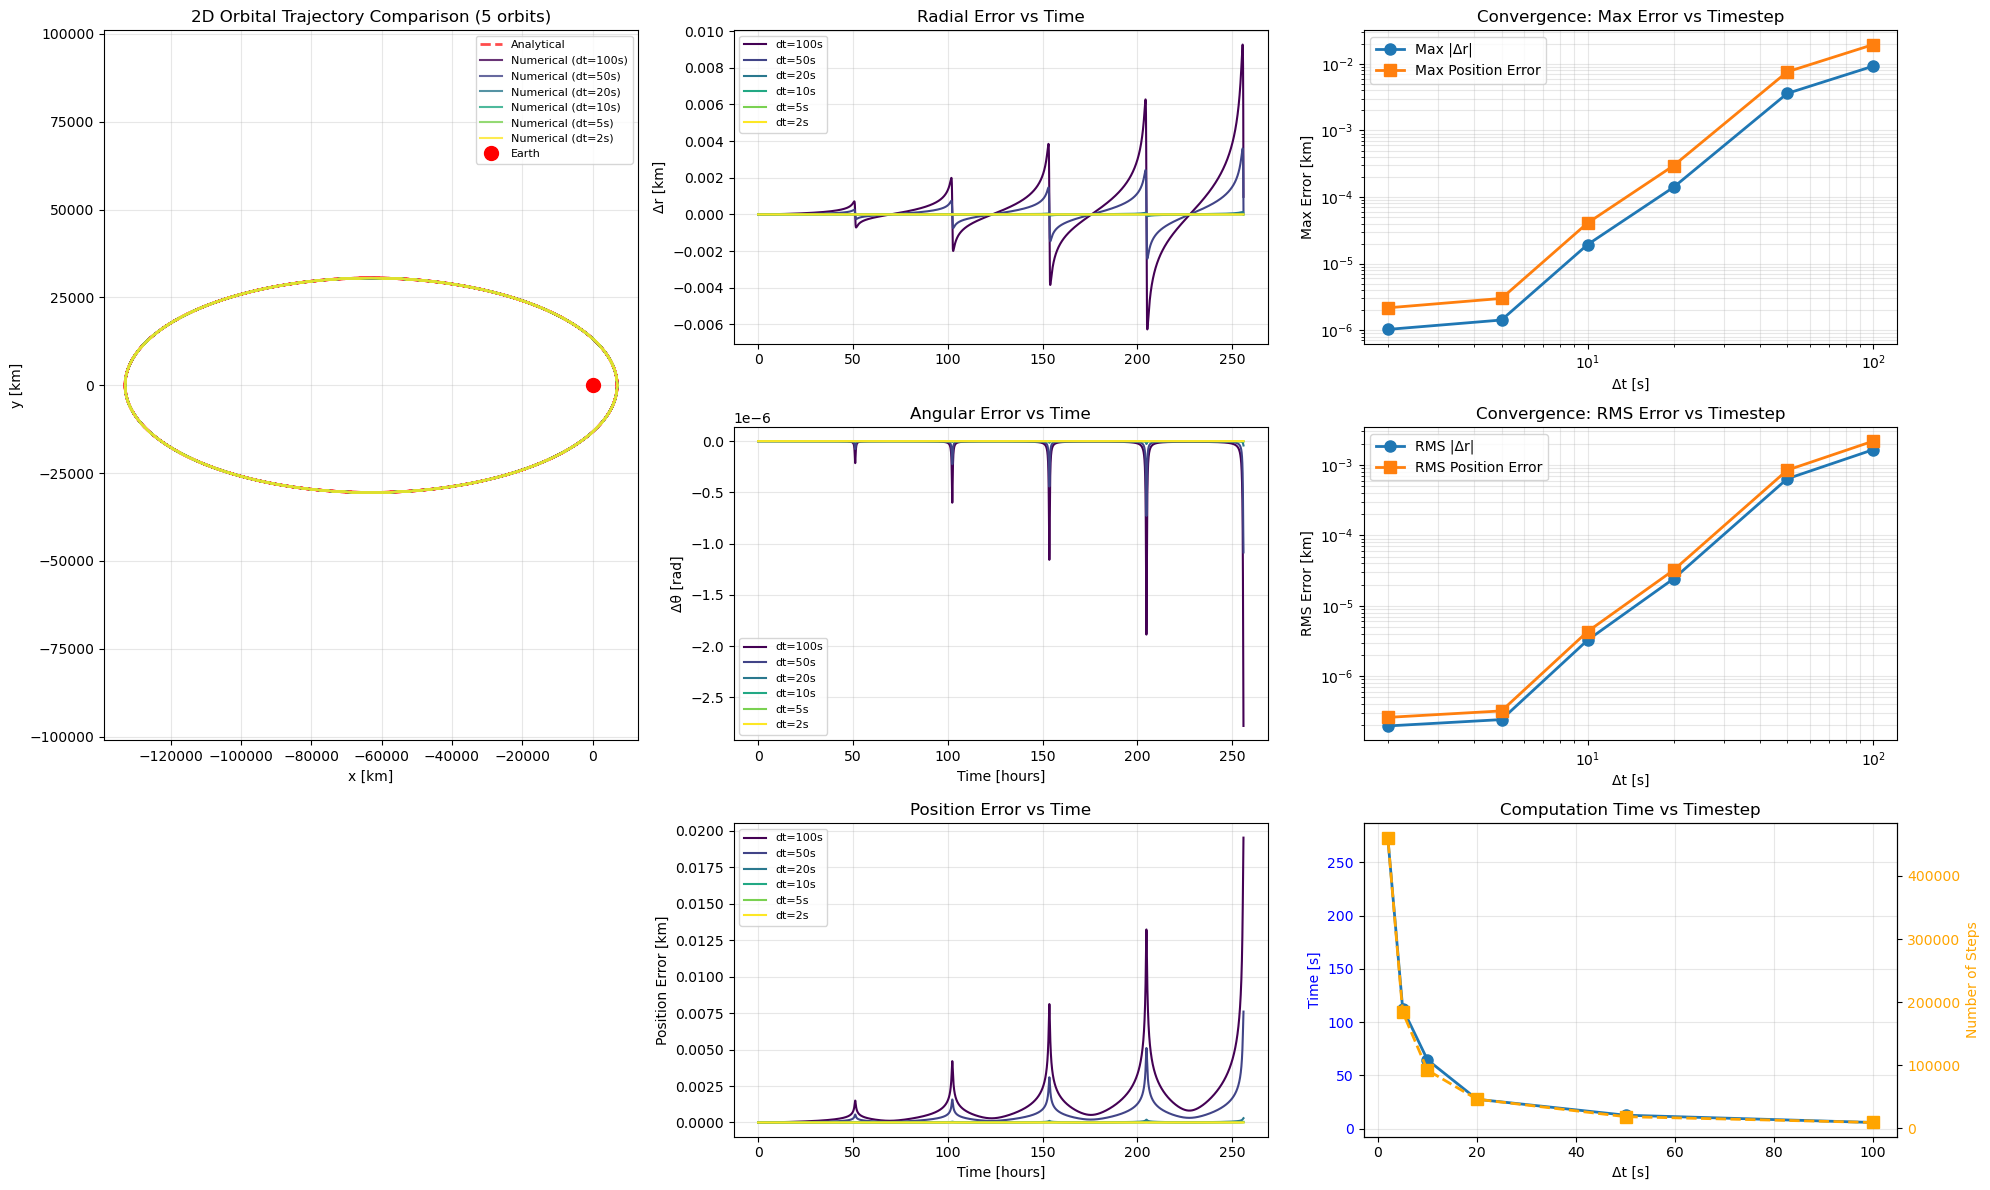

In [8]:
# Plot Cartesian results for multiple timesteps
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3)  # 3 rows, 3 columns

# Color map for different dt values
colors = plt.cm.viridis(np.linspace(0, 1, len(dt_values)))

# --- Plot 1: Trajectory comparison (spans rows 0-1, column 0)
ax1 = fig.add_subplot(gs[0:2, 0])
# Plot analytical trajectory (from first dt)
dt_ref = dt_values[0]
r_vec_analytical = results_cartesian[dt_ref]['r_vec_analytical']
ax1.plot(r_vec_analytical[:, 0], r_vec_analytical[:, 1], '--', label='Analytical', color='red', linewidth=2, alpha=0.7)
# Plot numerical trajectories for each dt
for i, dt in enumerate(dt_values):
    r_vec = results_cartesian[dt]['r_vec']
    ax1.plot(r_vec[:, 0], r_vec[:, 1], label=f'Numerical (dt={dt}s)', color=colors[i], linewidth=1.5, alpha=0.8)
ax1.plot(0, 0, 'ro', label='Earth', markersize=10)
ax1.set_xlabel('x [km]')
ax1.set_ylabel('y [km]')
ax1.set_title(f'2D Orbital Trajectory Comparison ({n_orbits} orbits)')
ax1.legend(fontsize=8, loc='upper right')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# --- Plot 2a: Δr vs Time (row 0, column 1)
ax2 = fig.add_subplot(gs[0, 1])
for i, dt in enumerate(dt_values):
    r = results_cartesian[dt]
    ax2.plot(r['t_vals'] / 3600, r['dr_error'], label=f'dt={dt}s', color=colors[i], linewidth=1.5)
ax2.set_ylabel('Δr [km]')
ax2.set_title('Radial Error vs Time')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# --- Plot 2b: Δθ vs Time (row 1, column 1)
ax3 = fig.add_subplot(gs[1, 1])
for i, dt in enumerate(dt_values):
    r = results_cartesian[dt]
    ax3.plot(r['t_vals'] / 3600, r['dtheta_error'], label=f'dt={dt}s', color=colors[i], linewidth=1.5)
ax3.set_xlabel('Time [hours]')
ax3.set_ylabel('Δθ [rad]')
ax3.set_title('Angular Error vs Time')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Plot 3: Position error vs Time (row 2, column 1)
ax4 = fig.add_subplot(gs[2, 1])
for i, dt in enumerate(dt_values):
    r = results_cartesian[dt]
    ax4.plot(r['t_vals'] / 3600, r['position_error'], label=f'dt={dt}s', color=colors[i], linewidth=1.5)
ax4.set_xlabel('Time [hours]')
ax4.set_ylabel('Position Error [km]')
ax4.set_title('Position Error vs Time')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# --- Plot 4: Max error vs dt (row 0, column 2)
ax5 = fig.add_subplot(gs[0, 2])
max_dr_errors = [np.max(np.abs(results_cartesian[dt]['dr_error'])) for dt in dt_values]
max_position_errors = [np.max(results_cartesian[dt]['position_error']) for dt in dt_values]
ax5.loglog(dt_values, max_dr_errors, 'o-', label='Max |Δr|', linewidth=2, markersize=8)
ax5.loglog(dt_values, max_position_errors, 's-', label='Max Position Error', linewidth=2, markersize=8)
ax5.set_xlabel('Δt [s]')
ax5.set_ylabel('Max Error [km]')
ax5.set_title('Convergence: Max Error vs Timestep')
ax5.legend()
ax5.grid(True, alpha=0.3, which='both')

# --- Plot 5: RMS error vs dt (row 1, column 2)
ax6 = fig.add_subplot(gs[1, 2])
rms_dr_errors = [np.sqrt(np.mean(results_cartesian[dt]['dr_error']**2)) for dt in dt_values]
rms_position_errors = [np.sqrt(np.mean(results_cartesian[dt]['position_error']**2)) for dt in dt_values]
ax6.loglog(dt_values, rms_dr_errors, 'o-', label='RMS |Δr|', linewidth=2, markersize=8)
ax6.loglog(dt_values, rms_position_errors, 's-', label='RMS Position Error', linewidth=2, markersize=8)
ax6.set_xlabel('Δt [s]')
ax6.set_ylabel('RMS Error [km]')
ax6.set_title('Convergence: RMS Error vs Timestep')
ax6.legend()
ax6.grid(True, alpha=0.3, which='both')

# --- Plot 6: Computation time vs dt (row 2, column 2)
ax7 = fig.add_subplot(gs[2, 2])
elapsed_times = [results_cartesian[dt]['elapsed_time'] for dt in dt_values]
N_values = [results_cartesian[dt]['N'] for dt in dt_values]
ax7.plot(dt_values, elapsed_times, 'o-', label='Computation Time', linewidth=2, markersize=8)
ax7_twin = ax7.twinx()
ax7_twin.plot(dt_values, N_values, 's--', color='orange', label='Number of Steps', linewidth=2, markersize=8)
ax7.set_xlabel('Δt [s]')
ax7.set_ylabel('Time [s]', color='blue')
ax7_twin.set_ylabel('Number of Steps', color='orange')
ax7.set_title('Computation Time vs Timestep')
ax7.tick_params(axis='y', labelcolor='blue')
ax7_twin.tick_params(axis='y', labelcolor='orange')
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
def state_cartesian_to_ks(cartesian_coordinates):
    """
    Transform Cartesian coordinates to Kustaanheimo-Stiefel state
    """
    x1, x2 = cartesian_coordinates
    x3 = 0 # TODO: Add z coordinate
    x_norm = np.sqrt(x1**2 + x2**2 + x3**2)
    
    # From Low-trush trajectory optimization using the kustaa-stiefel transformation Kevin Tracy and Zachary Manchester
    # TODO: compactify with vectorization
    y1 = 0.1
    y4 = np.sqrt(0.5 * (x_norm + x1) - y1 ** 2)
    y2 = (x2 * y1 + x3 * y4) / (x_norm + x1)
    y3 = (x3 * y1 - x2 * y4) / (x_norm + x1)
    ks_state = np.array([y1, y2, y3, y4])

    return ks_state

def cartesian_velocity2ks_state_dot(cartesian_velocity, ks_state):
    """
    Transform Cartesian velocity to Kustaanheimo-Stiefel fictitious velocity
    """
    x1_dot, x2_dot = cartesian_velocity
    x3_dot = 0 # TODO: Add z coordinate
    y1, y2, y3, y4 = ks_state
    
    # FromLow-trush trajectory optimization using the kustaa-stiefel transformation Kevin Tracy and Zachary Manchester
    # TODO: compactify with vectorization
    y1_dot = 0.5 * (y1 * x1_dot + y2 * x2_dot + y3 * x3_dot)
    y2_dot = 0.5 * (-y2 * x1_dot + y1 * x2_dot + y4 * x3_dot)
    y3_dot = 0.5 * (-y3 * x1_dot - y4 * x2_dot + y1 * x3_dot)
    y4_dot = 0.5 * (y4 * x1_dot - y3 * x2_dot + y2 * x3_dot)
    ks_state_dot = np.array([y1_dot, y2_dot, y3_dot, y4_dot])

    return ks_state_dot

def L_matrix(ks_state):
    """
    Compute the L matrix from the Kustaanheimo-Stiefel state
    """
    y1, y2, y3, y4 = ks_state
    
    L = np.array([[y1, -y2, -y3, y4],
                  [y2, y1, -y4, -y3],
                  [y3, y4, y1, y2],
                  [y4, -y3, y2, -y1]])
    return L
    
def ks_state2cartesian_coordinates(ks_state):
    """
    Transform Kustaanheimo-Stiefel state to Cartesian coordinates
    """
    L = L_matrix(ks_state)
    cartesian_coordinates = L @ ks_state

    return cartesian_coordinates[:3]

def ks_ode_system(t, ks_augmented_state):
    """
    Kustaanheimo-Stiefel transformed ODE system for two-body problem
    """
    ks_state, ks_state_dot = ks_augmented_state[:4], ks_augmented_state[4:8]
    h = (mu - 2 * ks_state_dot.T @ ks_state_dot) / (ks_state.T @ ks_state)
    ks_state_ddot = - h / 2 * ks_state
    
    return np.concatenate([ks_state_dot, ks_state_ddot])

In [10]:
# Initial conditions at perigee
ks_state0 = state_cartesian_to_ks(state0[:2])
ks_state_dot0 = cartesian_velocity2ks_state_dot(state0[2:], ks_state0)
ks_augmented_state0 = np.concatenate([ks_state0, ks_state_dot0])

In [11]:
# KS solutions for multiple timesteps
results_ks = {}

# Compute corresponding ds values from dt values
ds_values = [dt / a for dt in dt_values]

for dt, ds in tqdm(list(zip(dt_values, ds_values)), desc='KS dt/ds', leave=True):
    print(f"\nProcessing KS integration with dt = {dt} s, ds = {ds:.6f} s/km...")
    N = int(t_final / dt)
    s_vals = np.linspace(0, N * ds, N + 1)
    
    # KS RK4 integration
    ks_augmented_states = np.zeros((N + 1, 8))
    ks_augmented_states[0] = ks_augmented_state0
    r_vec_ks = np.zeros((N + 1, 2))
    r_vec_ks[0] = ks_state2cartesian_coordinates(ks_augmented_states[0][:4])[:2]
    start_time = time.time()
    for i in tqdm(range(N), desc=f'ds={ds:.6f}', leave=False):
        solution = solve_ivp(ks_ode_system, [s_vals[i], s_vals[i + 1]], ks_augmented_states[i], 
                             method='RK45', rtol=1e-10, atol=1e-10)
        ks_augmented_states[i + 1] = solution.y[:, -1]
        r_vec_ks[i + 1] = ks_state2cartesian_coordinates(ks_augmented_states[i + 1][:4])[:2]
    elapsed_time = time.time() - start_time
    x_ks, y_ks, theta_ks, r_vec_ks, r_vec_norm_ks = r_vecs2several_quantities(r_vec_ks)
    
    # Convert s to t for analytical solution
    t_vals_ks = np.zeros(N + 1)
    t_vals_ks[0] = 0
    for i in range(1, N + 1):
        t_vals_ks[i] = t_vals_ks[i-1] + (r_vec_norm_ks[i] + r_vec_norm_ks[i-1]) / 2 * ds
    
    # Analytical solution
    r_vec_analytical = np.zeros((N + 1, 2))
    r_vec_norm_analytical = np.zeros(N + 1)
    theta_analytical = np.zeros(N + 1)
    for i in range(N + 1):
        _, _, theta_analytical[i], r_vec_analytical[i], r_vec_norm_analytical[i] = analytical_solution(t_vals_ks[i], a, e)
    
    # Calculate errors
    dr_error = r_vec_norm_ks - r_vec_norm_analytical
    dtheta_error = np.mod(theta_ks - theta_analytical + np.pi, 2*np.pi) - np.pi
    position_error = np.linalg.norm(r_vec_ks - r_vec_analytical, axis=1)
    
    # Store results
    results_ks[dt] = {
        's_vals': s_vals,
        't_vals': t_vals_ks,
        'r_vec': r_vec_ks,
        'r_vec_norm': r_vec_norm_ks,
        'theta': theta_ks,
        'r_vec_analytical': r_vec_analytical,
        'r_vec_norm_analytical': r_vec_norm_analytical,
        'theta_analytical': theta_analytical,
        'dr_error': dr_error,
        'dtheta_error': dtheta_error,
        'position_error': position_error,
        'elapsed_time': elapsed_time,
        'N': N,
        'ds': ds
    }
    print(f"  Completed: {N} steps in {elapsed_time:.2f} s")

KS dt/ds:   0%|          | 0/6 [00:00<?, ?it/s]


Processing KS integration with dt = 100 s, ds = 0.001429 s/km...


ds=0.001429:   0%|          | 0/9215 [00:00<?, ?it/s]

  Completed: 9215 steps in 3.98 s

Processing KS integration with dt = 50 s, ds = 0.000714 s/km...


ds=0.000714:   0%|          | 0/18431 [00:00<?, ?it/s]

...

  Completed: 92156 steps in 37.72 s

Processing KS integration with dt = 5 s, ds = 0.000071 s/km...


ds=0.000071:   0%|          | 0/184313 [00:00<?, ?it/s]

  Completed: 184313 steps in 68.69 s

Processing KS integration with dt = 2 s, ds = 0.000029 s/km...


ds=0.000029:   0%|          | 0/460784 [00:00<?, ?it/s]

  Completed: 460784 steps in 164.80 s


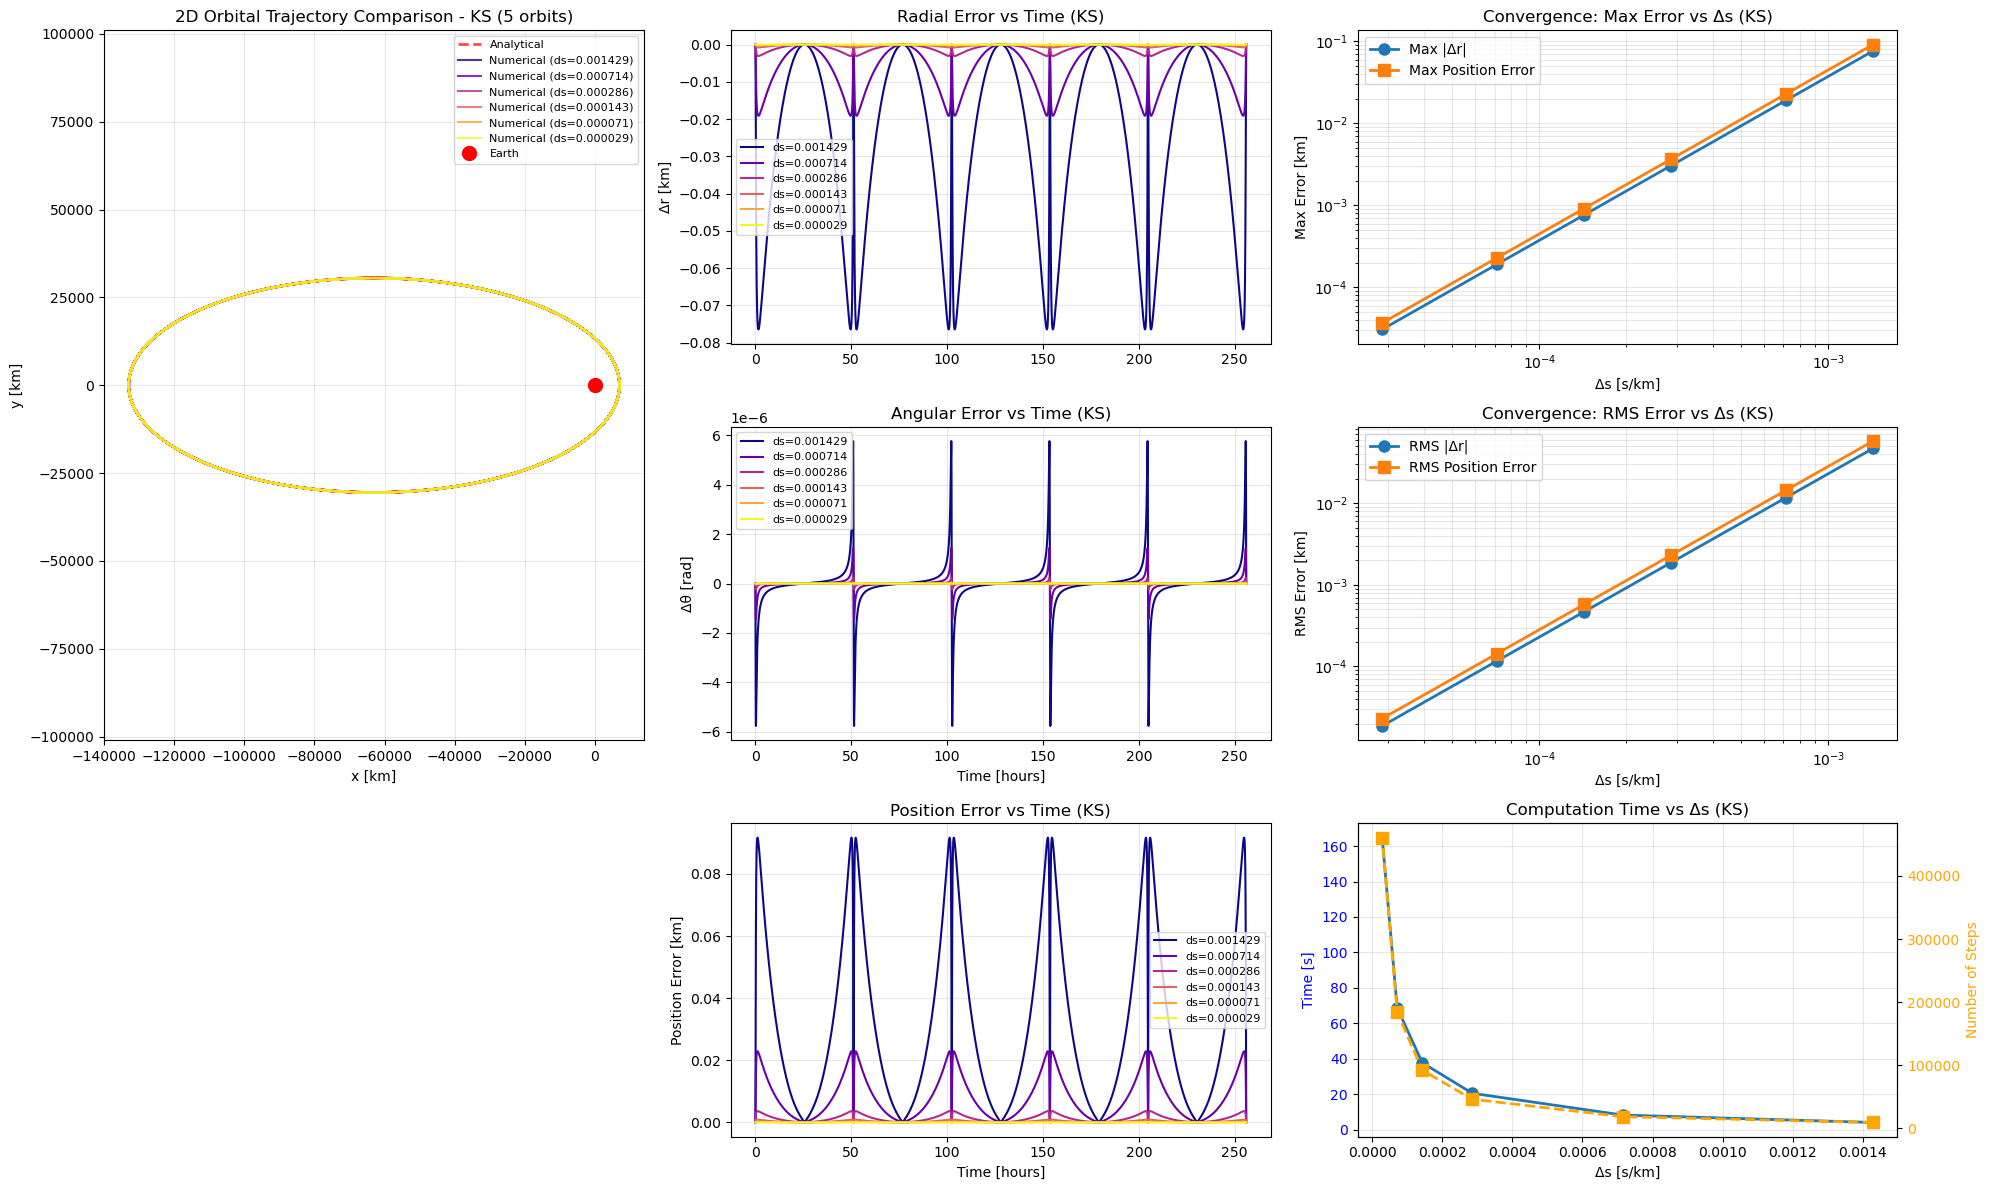

In [12]:
# Plot KS results for multiple timesteps
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3)  # 3 rows, 3 columns

# Color map for different dt/ds values
colors = plt.cm.plasma(np.linspace(0, 1, len(dt_values)))

# --- Plot 1: Trajectory comparison (spans rows 0-1, column 0)
ax1 = fig.add_subplot(gs[0:2, 0])
# Plot analytical trajectory (from first dt)
dt_ref = dt_values[0]
r_vec_analytical = results_ks[dt_ref]['r_vec_analytical']
ax1.plot(r_vec_analytical[:, 0], r_vec_analytical[:, 1], '--', label='Analytical', color='red', linewidth=2, alpha=0.7)
# Plot numerical trajectories for each dt
for i, dt in enumerate(dt_values):
    r_vec = results_ks[dt]['r_vec']
    ds = results_ks[dt]['ds']
    ax1.plot(r_vec[:, 0], r_vec[:, 1], label=f'Numerical (ds={ds:.6f})', color=colors[i], linewidth=1.5, alpha=0.8)
ax1.plot(0, 0, 'ro', label='Earth', markersize=10)
ax1.set_xlabel('x [km]')
ax1.set_ylabel('y [km]')
ax1.set_title(f'2D Orbital Trajectory Comparison - KS ({n_orbits} orbits)')
ax1.legend(fontsize=8, loc='upper right')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# --- Plot 2a: Δr vs Time (row 0, column 1)
ax2 = fig.add_subplot(gs[0, 1])
for i, dt in enumerate(dt_values):
    r = results_ks[dt]
    ax2.plot(r['t_vals'] / 3600, r['dr_error'], label=f'ds={r["ds"]:.6f}', color=colors[i], linewidth=1.5)
ax2.set_ylabel('Δr [km]')
ax2.set_title('Radial Error vs Time (KS)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# --- Plot 2b: Δθ vs Time (row 1, column 1)
ax3 = fig.add_subplot(gs[1, 1])
for i, dt in enumerate(dt_values):
    r = results_ks[dt]
    ax3.plot(r['t_vals'] / 3600, r['dtheta_error'], label=f'ds={r["ds"]:.6f}', color=colors[i], linewidth=1.5)
ax3.set_xlabel('Time [hours]')
ax3.set_ylabel('Δθ [rad]')
ax3.set_title('Angular Error vs Time (KS)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Plot 3: Position error vs Time (row 2, column 1)
ax4 = fig.add_subplot(gs[2, 1])
for i, dt in enumerate(dt_values):
    r = results_ks[dt]
    ax4.plot(r['t_vals'] / 3600, r['position_error'], label=f'ds={r["ds"]:.6f}', color=colors[i], linewidth=1.5)
ax4.set_xlabel('Time [hours]')
ax4.set_ylabel('Position Error [km]')
ax4.set_title('Position Error vs Time (KS)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# --- Plot 4: Max error vs ds (row 0, column 2)
ax5 = fig.add_subplot(gs[0, 2])
ds_values_plot = [results_ks[dt]['ds'] for dt in dt_values]
max_dr_errors = [np.max(np.abs(results_ks[dt]['dr_error'])) for dt in dt_values]
max_position_errors = [np.max(results_ks[dt]['position_error']) for dt in dt_values]
ax5.loglog(ds_values_plot, max_dr_errors, 'o-', label='Max |Δr|', linewidth=2, markersize=8)
ax5.loglog(ds_values_plot, max_position_errors, 's-', label='Max Position Error', linewidth=2, markersize=8)
ax5.set_xlabel('Δs [s/km]')
ax5.set_ylabel('Max Error [km]')
ax5.set_title('Convergence: Max Error vs Δs (KS)')
ax5.legend()
ax5.grid(True, alpha=0.3, which='both')

# --- Plot 5: RMS error vs ds (row 1, column 2)
ax6 = fig.add_subplot(gs[1, 2])
rms_dr_errors = [np.sqrt(np.mean(results_ks[dt]['dr_error']**2)) for dt in dt_values]
rms_position_errors = [np.sqrt(np.mean(results_ks[dt]['position_error']**2)) for dt in dt_values]
ax6.loglog(ds_values_plot, rms_dr_errors, 'o-', label='RMS |Δr|', linewidth=2, markersize=8)
ax6.loglog(ds_values_plot, rms_position_errors, 's-', label='RMS Position Error', linewidth=2, markersize=8)
ax6.set_xlabel('Δs [s/km]')
ax6.set_ylabel('RMS Error [km]')
ax6.set_title('Convergence: RMS Error vs Δs (KS)')
ax6.legend()
ax6.grid(True, alpha=0.3, which='both')

# --- Plot 6: Computation time vs ds (row 2, column 2)
ax7 = fig.add_subplot(gs[2, 2])
elapsed_times = [results_ks[dt]['elapsed_time'] for dt in dt_values]
N_values = [results_ks[dt]['N'] for dt in dt_values]
ax7.plot(ds_values_plot, elapsed_times, 'o-', label='Computation Time', linewidth=2, markersize=8)
ax7_twin = ax7.twinx()
ax7_twin.plot(ds_values_plot, N_values, 's--', color='orange', label='Number of Steps', linewidth=2, markersize=8)
ax7.set_xlabel('Δs [s/km]')
ax7.set_ylabel('Time [s]', color='blue')
ax7_twin.set_ylabel('Number of Steps', color='orange')
ax7.set_title('Computation Time vs Δs (KS)')
ax7.tick_params(axis='y', labelcolor='blue')
ax7_twin.tick_params(axis='y', labelcolor='orange')
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

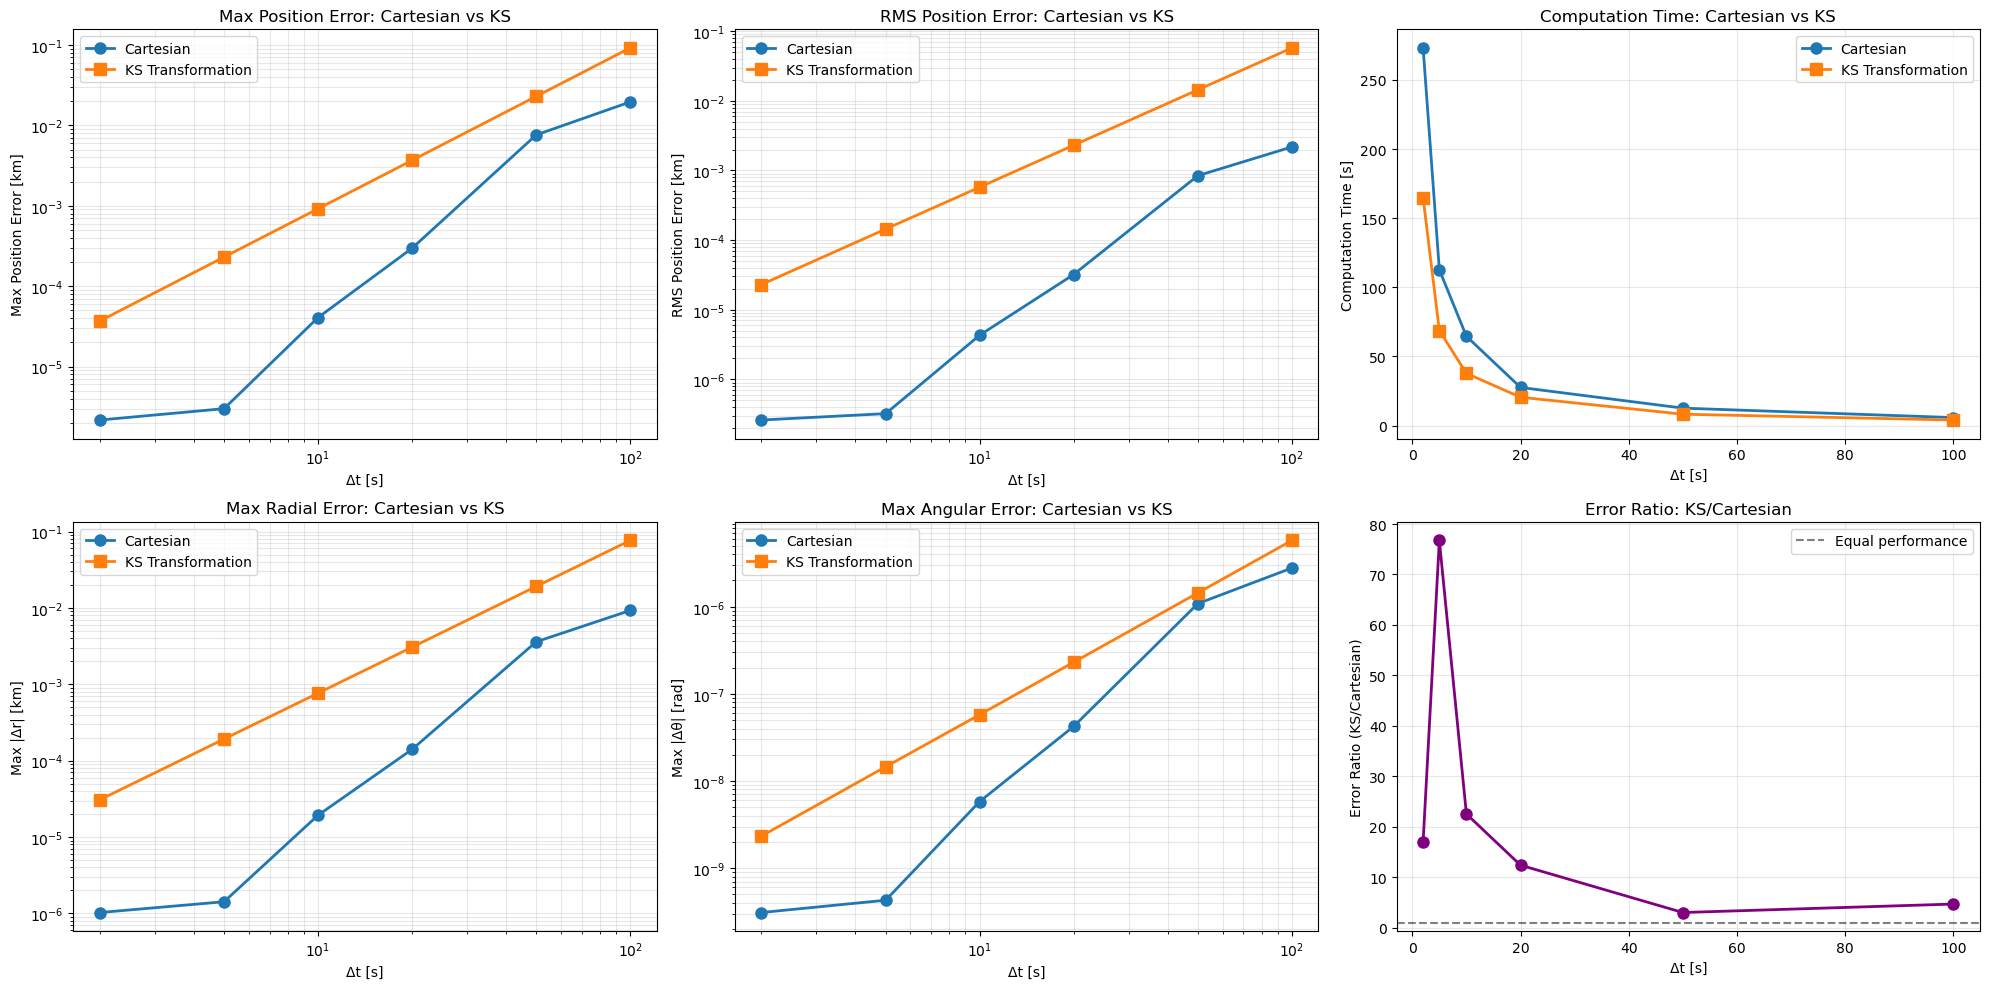

In [13]:
# Direct comparison: Cartesian vs KS transformation
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3)  # 2 rows, 3 columns

# Color map
colors = plt.cm.tab10(np.linspace(0, 1, len(dt_values)))

# --- Plot 1: Max error comparison (row 0, column 0)
ax1 = fig.add_subplot(gs[0, 0])
max_pos_err_cart = [np.max(results_cartesian[dt]['position_error']) for dt in dt_values]
max_pos_err_ks = [np.max(results_ks[dt]['position_error']) for dt in dt_values]
ax1.loglog(dt_values, max_pos_err_cart, 'o-', label='Cartesian', linewidth=2, markersize=8)
ax1.loglog(dt_values, max_pos_err_ks, 's-', label='KS Transformation', linewidth=2, markersize=8)
ax1.set_xlabel('Δt [s]')
ax1.set_ylabel('Max Position Error [km]')
ax1.set_title('Max Position Error: Cartesian vs KS')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

# --- Plot 2: RMS error comparison (row 0, column 1)
ax2 = fig.add_subplot(gs[0, 1])
rms_pos_err_cart = [np.sqrt(np.mean(results_cartesian[dt]['position_error']**2)) for dt in dt_values]
rms_pos_err_ks = [np.sqrt(np.mean(results_ks[dt]['position_error']**2)) for dt in dt_values]
ax2.loglog(dt_values, rms_pos_err_cart, 'o-', label='Cartesian', linewidth=2, markersize=8)
ax2.loglog(dt_values, rms_pos_err_ks, 's-', label='KS Transformation', linewidth=2, markersize=8)
ax2.set_xlabel('Δt [s]')
ax2.set_ylabel('RMS Position Error [km]')
ax2.set_title('RMS Position Error: Cartesian vs KS')
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

# --- Plot 3: Computation time comparison (row 0, column 2)
ax3 = fig.add_subplot(gs[0, 2])
time_cart = [results_cartesian[dt]['elapsed_time'] for dt in dt_values]
time_ks = [results_ks[dt]['elapsed_time'] for dt in dt_values]
ax3.plot(dt_values, time_cart, 'o-', label='Cartesian', linewidth=2, markersize=8)
ax3.plot(dt_values, time_ks, 's-', label='KS Transformation', linewidth=2, markersize=8)
ax3.set_xlabel('Δt [s]')
ax3.set_ylabel('Computation Time [s]')
ax3.set_title('Computation Time: Cartesian vs KS')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Max radial error comparison (row 1, column 0)
ax4 = fig.add_subplot(gs[1, 0])
max_dr_err_cart = [np.max(np.abs(results_cartesian[dt]['dr_error'])) for dt in dt_values]
max_dr_err_ks = [np.max(np.abs(results_ks[dt]['dr_error'])) for dt in dt_values]
ax4.loglog(dt_values, max_dr_err_cart, 'o-', label='Cartesian', linewidth=2, markersize=8)
ax4.loglog(dt_values, max_dr_err_ks, 's-', label='KS Transformation', linewidth=2, markersize=8)
ax4.set_xlabel('Δt [s]')
ax4.set_ylabel('Max |Δr| [km]')
ax4.set_title('Max Radial Error: Cartesian vs KS')
ax4.legend()
ax4.grid(True, alpha=0.3, which='both')

# --- Plot 5: Max angular error comparison (row 1, column 1)
ax5 = fig.add_subplot(gs[1, 1])
max_dtheta_err_cart = [np.max(np.abs(results_cartesian[dt]['dtheta_error'])) for dt in dt_values]
max_dtheta_err_ks = [np.max(np.abs(results_ks[dt]['dtheta_error'])) for dt in dt_values]
ax5.loglog(dt_values, max_dtheta_err_cart, 'o-', label='Cartesian', linewidth=2, markersize=8)
ax5.loglog(dt_values, max_dtheta_err_ks, 's-', label='KS Transformation', linewidth=2, markersize=8)
ax5.set_xlabel('Δt [s]')
ax5.set_ylabel('Max |Δθ| [rad]')
ax5.set_title('Max Angular Error: Cartesian vs KS')
ax5.legend()
ax5.grid(True, alpha=0.3, which='both')

# --- Plot 6: Error ratio (row 1, column 2)
ax6 = fig.add_subplot(gs[1, 2])
error_ratio = [max_pos_err_ks[i] / max_pos_err_cart[i] if max_pos_err_cart[i] > 0 else 1.0 
               for i in range(len(dt_values))]
ax6.plot(dt_values, error_ratio, 'o-', linewidth=2, markersize=8, color='purple')
ax6.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Equal performance')
ax6.set_xlabel('Δt [s]')
ax6.set_ylabel('Error Ratio (KS/Cartesian)')
ax6.set_title('Error Ratio: KS/Cartesian')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


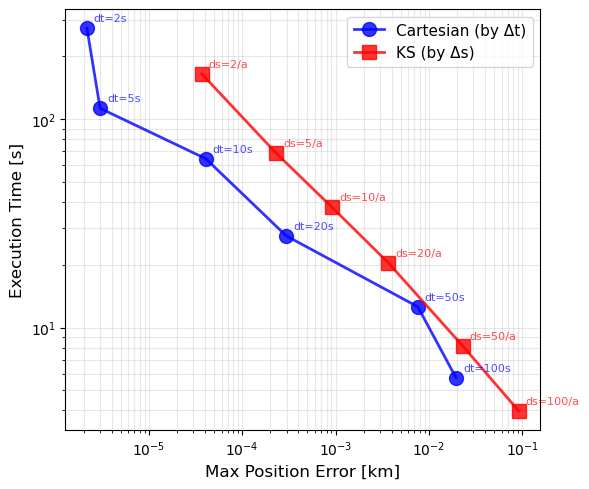

In [21]:
fig2, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.loglog(max_pos_err_cart, time_cart, 'o-', linewidth=2, markersize=10, 
         label='Cartesian (by Δt)', color='blue', alpha=0.8)
ax.loglog(max_pos_err_ks, time_ks, 's-', linewidth=2, markersize=10, 
         label='KS (by Δs)', color='red', alpha=0.8)

# Annotate Cartesian points
for i, dt in enumerate(dt_values):
    ax.annotate(f'dt={dt}s', 
                (max_pos_err_cart[i], time_cart[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.7, color='blue')

# Annotate KS points
for i, dt in enumerate(dt_values):
    ax.annotate(f'ds={dt}/a', 
                (max_pos_err_ks[i], time_ks[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.7, color='red')

ax.set_xlabel('Max Position Error [km]', fontsize=12)
ax.set_ylabel('Execution Time [s]', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')
# Note: Lower left (shorter time, lower error) = better performance

plt.tight_layout()
plt.show()
